In [87]:
import sys
from pathlib import Path
sys.path.append("/export/home/mickler/boa")

import os
os.environ["PROJECT_ROOT"] = "/export/home/mickler/boa"

import hydra
from hydra import initialize, compose
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import torch

# Monkey patch the HydraConfig.get method to avoid the error
from hydra.core.hydra_config import HydraConfig

# Store the original method before patching
_original_get = HydraConfig.get.__func__

@classmethod 
def patched_get(cls):
    try:
        instance = cls.instance()
        if instance.cfg is None:
            raise ValueError("HydraConfig was not set")
        return instance.cfg.hydra
    except ValueError:
        # Return a minimal mock config when HydraConfig is not set
        from omegaconf import DictConfig
        mock_config = DictConfig({
            "job": {
                "override_dirname": "",
                "num": "0"
            },
            "runtime": {
                "output_dir": "/tmp/hydra_fallback"
            },
            "sweep": {
                "dir": "/tmp/hydra_sweep"
            }
        })
        return mock_config

# Apply the monkey patch
HydraConfig.get = patched_get

# Import and register the custom resolvers from your project
from boa.utils.omegaconf_resolvers import *

from boa.model.module import ChgLightningModule

run_path = Path("/export/scratch/mklockow/boa/models/train/runs/437_qm9_small_qm9_vasp_small__seed-2")
best_ckpt = (run_path / "best_model_path.txt").read_text().strip()
model_path = run_path / best_ckpt
config_path = run_path / "config.yaml"

# cfg = OmegaConf.load(config_path)

with initialize(config_path="../configs", version_base="1.1"):
    cfg = compose(config_name="train.yaml", overrides=["data=md", "data.datamodule.dataset.mol_name=benzene", "data.datamodule.dataset.n_probe=null", "data.basis_info.basis=def2-svp"]) # def2-svp

# First instantiate datamodule to get metadata
datamodule = hydra.utils.instantiate(cfg.data.datamodule, _recursive_=False)
datamodule.setup("fit")  # This creates the metadata
metadata = datamodule.metadata

print(f"Metadata: {metadata}")

# Now instantiate model with proper metadata
model = hydra.utils.instantiate(cfg.model, train=cfg, _recursive_=False, metadata=metadata)
# model = ChgLightningModule.load_from_checkpoint(model_path, map_location="cpu")

/export/home/mickler/boa/.venv/lib/python3.11/site-packages/IPython/core/async_helpers.py:128: UserWarning: 
'hydra/launcher/basic' is validated against ConfigStore schema with the same name.
This behavior is deprecated in Hydra 1.1 and will be removed in Hydra 1.2.
See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/automatic_schema_matching for migration instructions.
  coro.send(None)


Precomputing train density from FFT coefficients ...
Precomputing test density from FFT coefficients ...
Precomputing test density from FFT coefficients ...
Metadata: {'target_mean': 0.04942677915096283, 'target_var': 0.09023565798997879, 'avg_num_neighbors': 3, 'unique_atom_types': [1, 6]}
Unique atom types: [1 6]
Using radial correction for GTOs.
Using radial correction for GTOs.
Metadata: {'target_mean': 0.04942677915096283, 'target_var': 0.09023565798997879, 'avg_num_neighbors': 3, 'unique_atom_types': [1, 6]}
Unique atom types: [1 6]
Using radial correction for GTOs.
Using radial correction for GTOs.


/export/home/mickler/boa/boa/model/module.py:124: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(gto.contraction, dtype=torch.int64),


BOA(
  (boa_stack): BoaBlockStack(
    (blocks): ModuleList(
      (0-3): 4 x BoaBlock(
        (linear0): StableLinearNodeOperator(
          (stable_linear_node_operators): ModuleDict(
            (1): StableLinearNodeOperatorAtom(
              (linear1): Linear(4x0e+1x1o -> 4x0e+1x1o | 17 weights)
            )
            (6): StableLinearNodeOperatorAtom(
              (linear1): Linear(7x0e+4x1o+1x2e -> 7x0e+4x1o+1x2e | 66 weights)
            )
          )
        )
        (linear1): StableLinearNodeOperator(
          (stable_linear_node_operators): ModuleDict(
            (1): StableLinearNodeOperatorAtom(
              (linear1): Linear(4x0e+1x1o -> 4x0e+1x1o | 17 weights)
            )
            (6): StableLinearNodeOperatorAtom(
              (linear1): Linear(7x0e+4x1o+1x2e -> 7x0e+4x1o+1x2e | 66 weights)
            )
          )
        )
        (linear2): StableLinearNodeOperator(
          (stable_linear_node_operators): ModuleDict(
            (1): StableLinearNo

In [88]:
# datamodule.setup("fit")  # Already called in the first cell
val_set = datamodule.val_dataset
sample = val_set[0]
print(sample)

OFData(
  pos=[12, 3],
  atomic_numbers=[12],
  coeffs=[186],
  atom_ind=[12],
  n_basis_per_atom=[12],
  atom_ptr=[12],
  basis_function_ind=[186],
  coeff_ind_to_node_ind=[186],
  dual_basis_integrals=[186],
  irreps_per_atom=[12],
  representations={
    pos=Representation.NONE,
    atomic_numbers=Representation.NONE,
    coeffs=Representation.VECTOR,
    ground_state_coeffs=Representation.VECTOR,
    gradient_label=Representation.GRADIENT,
    energy_label=Representation.SCALAR,
    has_energy_label=Representation.NONE,
    atom_ind=Representation.NONE,
    n_basis_per_atom=Representation.NONE,
    atom_ptr=Representation.NONE,
    basis_function_ind=Representation.NONE,
    coeff_ind_to_node_ind=Representation.NONE,
    dual_basis_integrals=Representation.DUAL_VECTOR,
    mol_id=Representation.NONE,
    scf_iteration=Representation.NONE,
    irreps_per_atom=Representation.NONE,
    representations=Representation.NONE,
    n_probe=Representation.NONE,
    cell=Representation.VECTOR

In [89]:
import pyvista as pv

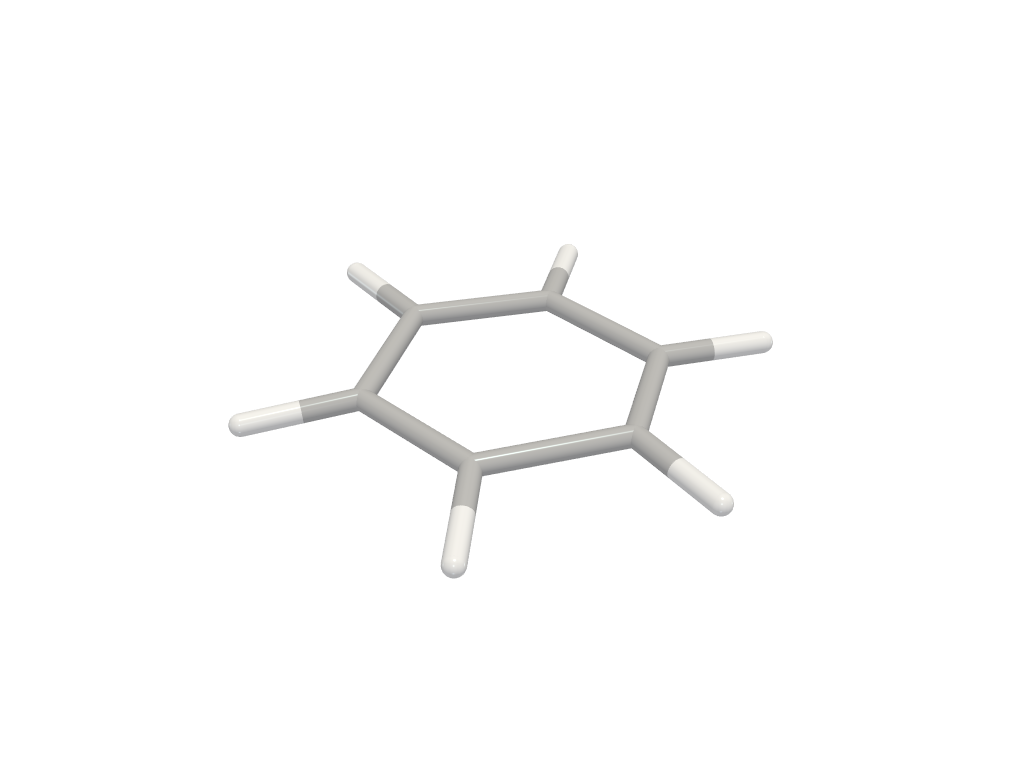

In [90]:
import pyvista as pv
from mldft.utils.visualize_3d import get_sticks_mesh_dict
from mldft.utils.molecules import build_molecule_ofdata

# Switch to static backend for better sphere rendering in notebooks
pv.set_jupyter_backend('static')  # Use static backend for notebooks
# pv.set_jupyter_backend('html')    # Interactive with panel
# pv.set_jupyter_backend('trame')    # Interactive with trame
# pv.set_jupyter_backend('pythreejs') # Interactive with pythreejs

mol = build_molecule_ofdata(sample)

pl = pv.Plotter(notebook=True)
pl.add_mesh(**get_sticks_mesh_dict(mol))
pl.show()

In [91]:
model.gto_dict

ModuleDict(
  (1): GTOs(Lmax=1, n_orbitals=5, n_contracted=5.0, outdim=7)
  (6): GTOs(Lmax=2, n_orbitals=12, n_contracted=12.0, outdim=24)
)

In [92]:
import numpy as np
from scipy.spatial.distance import cdist

def compute_gaussian_product_peaks(sample, gto_dict, min_distance_threshold=0.1):
    """
    Compute the peaks of Gaussian products for neighboring atoms within cutoff.
    
    When two Gaussians exp(-α₁|r-R₁|²) and exp(-α₂|r-R₂|²) are multiplied,
    the product is a Gaussian with peak at: R_peak = (α₁R₁ + α₂R₂)/(α₁ + α₂)
    
    Args:
        sample: Molecule data containing positions, atomic numbers, edge_index
        gto_dict: Dictionary of GTOs for each atom type
        min_distance_threshold: Minimum distance between peaks to avoid duplicates
    
    Returns:
        peak_coords: Tensor of shape (N_peaks, 3) with peak coordinates
        peak_info: List of dictionaries with metadata for each peak
    """
    
    # Get molecular information
    atomic_numbers = sample.atomic_numbers
    positions = sample.pos
    edge_index = sample.edge_index
    
    # Store all peaks and their metadata
    all_peaks = []
    peak_info = []
    
    # Process each edge (atom pair)
    for edge_idx in range(edge_index.shape[1]):
        atom_i_idx = edge_index[0, edge_idx].item()
        atom_j_idx = edge_index[1, edge_idx].item()
        
        # Skip self-loops for now (we could include them for completeness)
        if atom_i_idx == atom_j_idx:
            continue
            
        atom_i_type = atomic_numbers[atom_i_idx].item()
        atom_j_type = atomic_numbers[atom_j_idx].item()
        
        pos_i = positions[atom_i_idx]
        pos_j = positions[atom_j_idx]
        
        # Check if atoms are within cutoff distance
        distance = torch.norm(pos_i - pos_j).item()
        
        # Get GTOs for both atoms
        gto_i = gto_dict[str(atom_i_type)]
        gto_j = gto_dict[str(atom_j_type)]
        
        if distance > max(gto_i.cutoff, gto_j.cutoff):
            continue
            
        # Get exponents for both atoms
        expos_i = gto_i.expos
        expos_j = gto_j.expos
        
        # Compute peaks for all combinations of basis functions
        for k, exp_i in enumerate(expos_i):
            for l, exp_j in enumerate(expos_j):
                # Peak of product of two Gaussians: weighted average of centers
                alpha_i = exp_i.item()
                alpha_j = exp_j.item()
                
                # Peak position: (α₁R₁ + α₂R₂)/(α₁ + α₂)
                peak_pos = (alpha_i * pos_i + alpha_j * pos_j) / (alpha_i + alpha_j)
                
                # Store peak information
                peak_info_dict = {
                    'atom_i_idx': atom_i_idx,
                    'atom_j_idx': atom_j_idx,
                    'atom_i_type': atom_i_type,
                    'atom_j_type': atom_j_type,
                    'atom_i_pos': pos_i.clone(),
                    'atom_j_pos': pos_j.clone(),
                    'basis_i_idx': k,
                    'basis_j_idx': l,
                    'exp_i': alpha_i,
                    'exp_j': alpha_j,
                    'distance': distance,
                    'peak_pos': peak_pos.clone()
                }
                
                all_peaks.append(peak_pos)
                peak_info.append(peak_info_dict)
    
    if not all_peaks:
        return torch.empty(0, 3), []
    
    # Convert to tensor
    peak_coords = torch.stack(all_peaks)
    
    # Remove duplicates that are too close together
    if min_distance_threshold > 0:
        unique_peaks = []
        unique_info = []
        
        for i, (peak, info) in enumerate(zip(peak_coords, peak_info)):
            is_duplicate = False
            for existing_peak in unique_peaks:
                if torch.norm(peak - existing_peak) < min_distance_threshold:
                    is_duplicate = True
                    break
            
            if not is_duplicate:
                unique_peaks.append(peak)
                unique_info.append(info)
        
        if unique_peaks:
            peak_coords = torch.stack(unique_peaks)
            peak_info = unique_info
        else:
            peak_coords = torch.empty(0, 3)
            peak_info = []
    
    return peak_coords, peak_info

# Test the function
peaks, peak_info = compute_gaussian_product_peaks(sample, model.gto_dict, min_distance_threshold=0)
print(f"Found {len(peaks)} unique Gaussian product peaks")
print(f"Peak coordinates shape: {peaks.shape}")

Found 6780 unique Gaussian product peaks
Peak coordinates shape: torch.Size([6780, 3])


In [157]:
def get_atoms_only_mesh_dict(sample, atom_radius=0.2, resolution=20):
    """
    Create an atoms-only representation for a molecule (no bonds).
    
    Args:
        sample: Molecule data containing positions and atomic numbers
        atom_radius: The radius of the spheres representing atoms
        resolution: The resolution of the spheres
        
    Returns:
        A dictionary with keyword arguments to pass to pyvista.Plotter.add_mesh
    """
    # Color mapping for atoms
    ATOM_COLORS = {
        1: "#eeeeee",   # H - white
        6: "#666666",   # C - gray
        7: "#8f8fff",   # N - blue
        8: "#f00000",   # O - red
        9: "#ffff00",   # F - yellow
        15: "#ffa500",  # P - orange
        16: "#ffc832",  # S - yellow
        19: "#42f4ee",  # K - cyan
        0: "#3f3f3f",   # Unknown - dark gray
    }
    
    # Get positions and atomic numbers directly from sample
    positions = sample.pos  # Already in Bohr
    atomic_numbers = sample.atomic_numbers
    
    mesh_elements = []
    
    # Create spheres for atoms only
    for i, (pos, atomic_num) in enumerate(zip(positions, atomic_numbers)):
        atomic_num = atomic_num.item()
        color_id = list(ATOM_COLORS.keys()).index(atomic_num) if atomic_num in ATOM_COLORS else list(ATOM_COLORS.keys()).index(0)
        
        sphere = pv.Sphere(
            center=pos.numpy(),
            radius=atom_radius,
            phi_resolution=resolution,
            theta_resolution=resolution,
        )
        sphere["color_ids"] = np.ones(sphere.n_cells) * color_id
        mesh_elements.append(sphere)
    
    merged_mesh = pv.MultiBlock(mesh_elements).combine().extract_surface()
    add_mesh_kwargs = dict(
        mesh=merged_mesh,
        smooth_shading=True,
        diffuse=0.5,
        specular=0.5,
        ambient=0.5,
        clim=(0, len(ATOM_COLORS)-1),
        cmap=list(ATOM_COLORS.values()),
        show_scalar_bar=False,
    )
    return add_mesh_kwargs

def find_isosurface_value(cube_array, quantile=0.9, p=2):
    """Find an isosurface value for a cube array, such that the isosurface contains a given
    fraction of the total mass. Adapted from visualize_3d.py"""
    cube_array = np.abs(cube_array).flatten()
    mass = cube_array**p
    total_mass = mass.sum()
    mass_sorted = np.sort(mass)[::-1]
    ind = np.searchsorted(np.cumsum(mass_sorted), total_mass * quantile)
    isosurface_value = mass_sorted[ind] ** (1 / p)
    return isosurface_value

def compute_gaussian_product_3d(peak_info_single, grid_resolution=50, extent=3.0):
    """
    Compute the 3D Gaussian product function on a grid around the peak.
    
    Args:
        peak_info_single: Single peak info dictionary
        grid_resolution: Number of grid points in each dimension
        extent: Half-size of the grid in Bohr
        
    Returns:
        grid: PyVista structured grid with Gaussian values
    """
    # Extract information
    pos_i = peak_info_single['atom_i_pos']
    pos_j = peak_info_single['atom_j_pos']
    alpha_i = peak_info_single['exp_i']
    alpha_j = peak_info_single['exp_j']
    peak_pos = peak_info_single['peak_pos']
    
    # Create 3D grid centered around the peak
    x = torch.linspace(peak_pos[0] - extent, peak_pos[0] + extent, grid_resolution)
    y = torch.linspace(peak_pos[1] - extent, peak_pos[1] + extent, grid_resolution)
    z = torch.linspace(peak_pos[2] - extent, peak_pos[2] + extent, grid_resolution)
    
    # Create meshgrid
    X, Y, Z = torch.meshgrid(x, y, z, indexing='ij')
    grid_points = torch.stack([X.flatten(), Y.flatten(), Z.flatten()], dim=1)
    
    # Compute Gaussian product at each grid point
    # G1(r) = exp(-α1 * |r - R1|²)
    # G2(r) = exp(-α2 * |r - R2|²)
    # Product = G1(r) * G2(r)
    
    dist_sq_i = torch.sum((grid_points - pos_i.unsqueeze(0))**2, dim=1)
    dist_sq_j = torch.sum((grid_points - pos_j.unsqueeze(0))**2, dim=1)
    
    gaussian_i = torch.exp(-alpha_i * dist_sq_i)
    gaussian_j = torch.exp(-alpha_j * dist_sq_j)
    product = gaussian_i * gaussian_j
    
    # Reshape back to 3D
    product_3d = product.reshape(grid_resolution, grid_resolution, grid_resolution)
    
    # Create PyVista structured grid
    grid = pv.StructuredGrid(X.numpy(), Y.numpy(), Z.numpy())
    grid["gaussian_product"] = product_3d.flatten()
    
    return grid

In [158]:
# Find indices of H-H (hydrogen-hydrogen) connections
hh_indices = []
for i, info in enumerate(peak_info):
    atom_i_type = info['atom_i_type']
    atom_j_type = info['atom_j_type']
    
    # Check if both atoms are hydrogen (atomic number 1)
    if atom_i_type == 1 and atom_j_type == 1:
        hh_indices.append(i)

print(f"Found {len(hh_indices)} H-H connections out of {len(peak_info)} total peaks")
print(f"H-H connection indices: {hh_indices[:20]}...")  # Show first 20
print(f"Percentage of H-H connections: {len(hh_indices)/len(peak_info)*100:.1f}%")

# Also find other connection types for comparison
cc_indices = []  # Carbon-Carbon
ch_indices = []  # Carbon-Hydrogen

for i, info in enumerate(peak_info):
    atom_i_type = info['atom_i_type']
    atom_j_type = info['atom_j_type']
    
    # Carbon-Carbon connections
    if atom_i_type == 6 and atom_j_type == 6:
        cc_indices.append(i)
    
    # Carbon-Hydrogen connections (either C-H or H-C)
    if (atom_i_type == 6 and atom_j_type == 1) or (atom_i_type == 1 and atom_j_type == 6):
        ch_indices.append(i)

print(f"\nConnection type summary:")
print(f"H-H connections: {len(hh_indices)} ({len(hh_indices)/len(peak_info)*100:.1f}%)")
print(f"C-C connections: {len(cc_indices)} ({len(cc_indices)/len(peak_info)*100:.1f}%)")
print(f"C-H connections: {len(ch_indices)} ({len(ch_indices)/len(peak_info)*100:.1f}%)")

Found 300 H-H connections out of 6780 total peaks
H-H connection indices: [5400, 5401, 5402, 5403, 5404, 5405, 5406, 5407, 5408, 5409, 5410, 5411, 5412, 5413, 5414, 5415, 5416, 5417, 5418, 5419]...
Percentage of H-H connections: 4.4%

Connection type summary:
H-H connections: 300 (4.4%)
C-C connections: 4320 (63.7%)
C-H connections: 2160 (31.9%)


Selected peak between atoms 7 and 6
Atom types: 1 and 1
Basis functions: 0 and 0
Peak position: tensor([4.3045, 7.1751, 5.2822])


2025-09-23 14:33:19.694 (19174.513s) [    72BE5EEE6740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5bc11c976ea0): Unable to eglMakeCurrent: 12291
2025-09-23 14:33:19.728 (19174.548s) [    72BE5EEE6740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5bc11c97a910): Unable to eglMakeCurrent: 12291
2025-09-23 14:33:20.018 (19174.838s) [    72BE5EEE6740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5bc11c976ea0): Unable to eglMakeCurrent: 12291


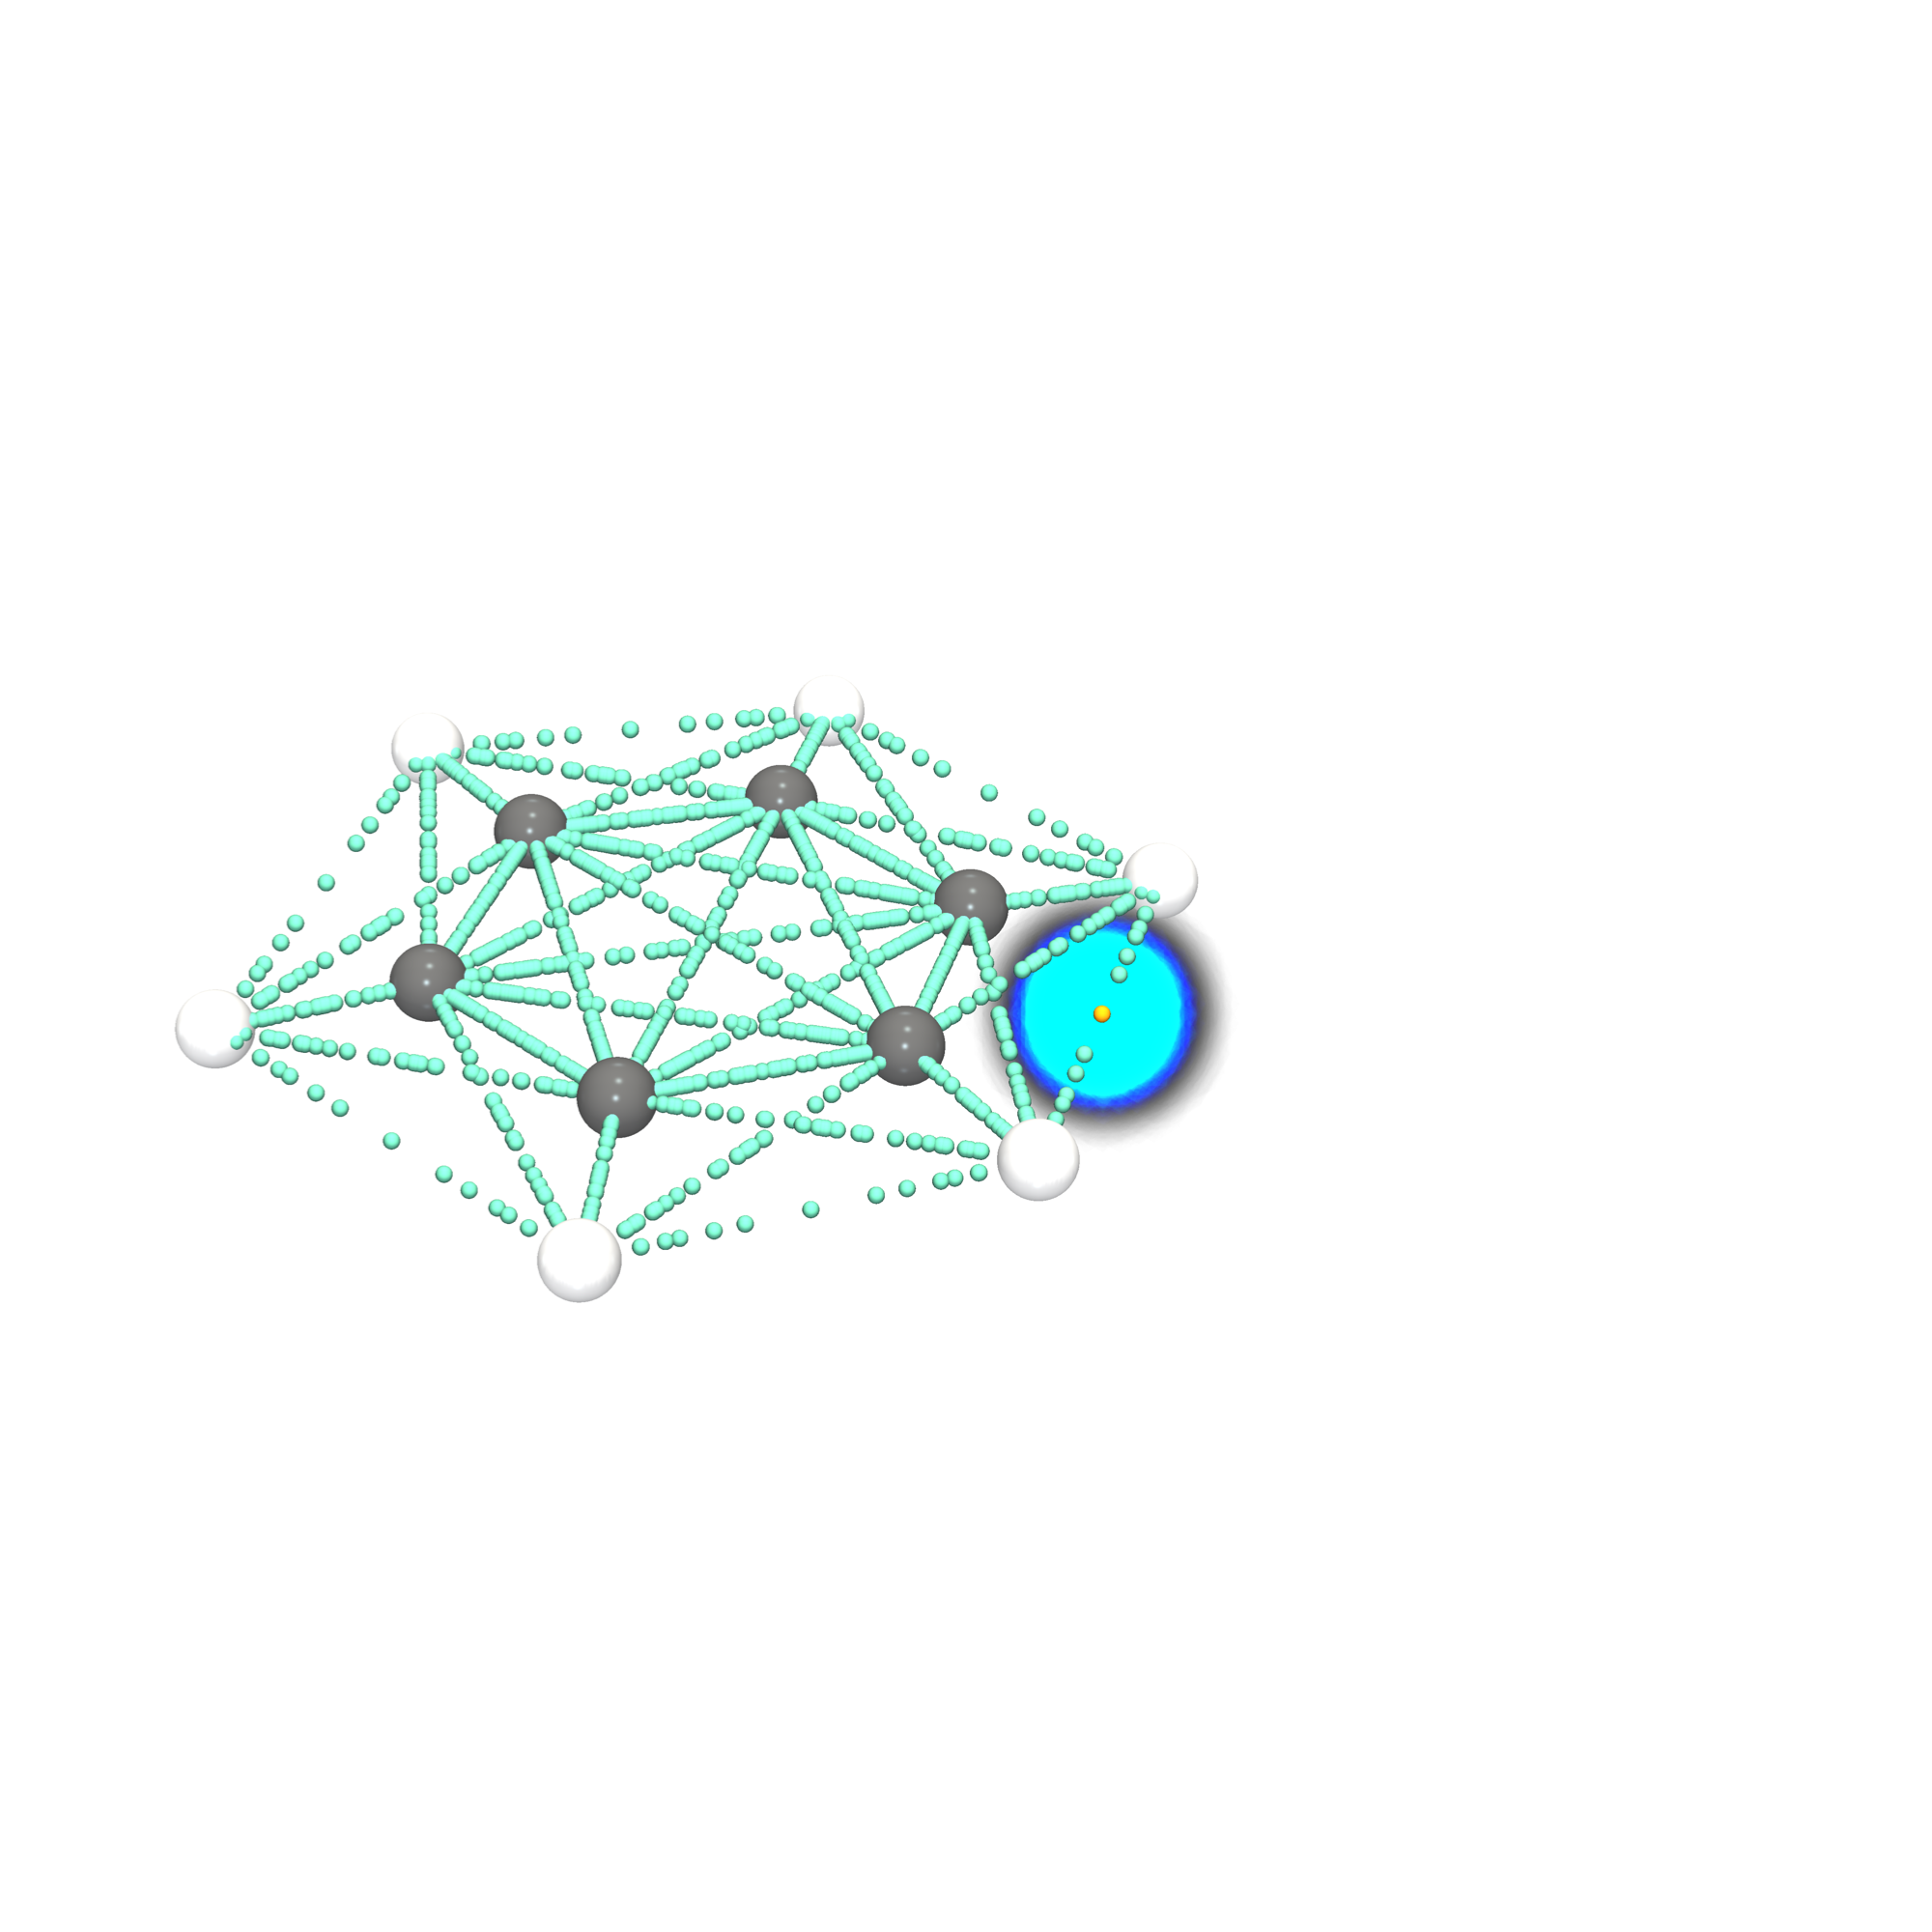

In [161]:
selected_peak_info = peak_info[5400]  # Pick first peak
selected_peak_pos = selected_peak_info['peak_pos']

print(f"Selected peak between atoms {selected_peak_info['atom_i_idx']} and {selected_peak_info['atom_j_idx']}")
print(f"Atom types: {selected_peak_info['atom_i_type']} and {selected_peak_info['atom_j_type']}")
print(f"Basis functions: {selected_peak_info['basis_i_idx']} and {selected_peak_info['basis_j_idx']}")
print(f"Peak position: {selected_peak_pos}")

# Compute 3D Gaussian product with higher resolution
gaussian_grid = compute_gaussian_product_3d(selected_peak_info, grid_resolution=50, extent=3.0)

pv.set_jupyter_backend('static')    # Static backend for better rendering

# Create high-quality visualization with advanced rendering
plotter = pv.Plotter(notebook=True, window_size=[2000, 2000])  # Higher resolution window

# Set advanced rendering options
plotter.enable_shadows()  # Enable shadows for depth perception
plotter.enable_anti_aliasing()  # Smooth edges
# Remove background color for transparent background
# plotter.set_background('#1a1a2e')  # Commented out for transparent background

# Add sophisticated lighting
light = pv.Light(position=(10, 10, 10), light_type='headlight')
light.intensity = 0.8
plotter.add_light(light)

# Add fill light
fill_light = pv.Light(position=(-5, -5, 5), light_type='scene light')
fill_light.intensity = 0.3
plotter.add_light(fill_light)

# Add molecular structure with enhanced colors
plotter.add_mesh(**get_atoms_only_mesh_dict(sample, atom_radius=0.2, resolution=40))  # Higher sphere resolution

# Add all peaks in sophisticated purple/magenta (instead of red)
plotter.add_points(peaks.numpy(), color='#60bc9cff', point_size=40, render_points_as_spheres=True, 
                  metallic=0., roughness=0.4)  # Sophisticated red with material properties

# Add selected peak in bright gold (instead of yellow)
plotter.add_points(selected_peak_pos.numpy().reshape(1, -1), color='#f39c12', point_size=40, 
                  render_points_as_spheres=True, metallic=0., roughness=0.2)  # Gold with metallic finish

# Add Gaussian product as volume with improved visibility
gaussian_values = gaussian_grid["gaussian_product"]

# Normalize Gaussian values with better contrast
gaussian_normalized = np.abs(gaussian_values)
gaussian_max = gaussian_normalized.max()
if gaussian_max > 0:
    gaussian_normalized = gaussian_normalized / gaussian_max

# Create RGBA values with improved blue color scheme
rgba = np.zeros((gaussian_grid.n_points, 4), np.uint8)

# Enhanced blue color scheme with better intensity gradation
# Use a deeper, more saturated blue that will be more visible
base_color = np.array([0, 100, 255])  # Deep blue (instead of cyan-blue)

color_intensity = gaussian_normalized
for i in range(3):  # RGB channels
    rgba[:, i] = (base_color[i] * color_intensity).astype(np.uint8)

# Improved opacity calculation with better threshold and scaling
opac = np.abs(gaussian_values)
opac_threshold = find_isosurface_value(opac, 0.15, p=1)  # Lower threshold (was 0.25)
if opac_threshold > 0:
    opac = opac / opac_threshold
    
# Apply non-linear opacity scaling for better visibility
opac = opac ** 0.4  # Power scaling to make more of the volume visible
opac = np.clip(opac, 0, 1)

# Increase maximum opacity for better visibility
max_opacity = 0.4  # Increased from 0.4
rgba[:, -1] = (opac * max_opacity * 255).astype(np.uint8)

gaussian_grid["plot_scalars"] = rgba

# Add volume to plotter with improved settings
vol = plotter.add_volume(
    gaussian_grid,
    opacity_unit_distance=4,  # Reduced for denser appearance (was 6)
    scalars="plot_scalars",
)
vol.prop.interpolation_type = "linear"

# Set camera to an attractive angle
plotter.camera_position = 'iso'
plotter.camera.zoom(1.2)

plotter.show()
# Save with transparent background
_ = plotter.screenshot('bonds.png', transparent_background=True, window_size=(2000, 2000))

### Theory

When two Gaussian functions are multiplied:
- $G_1(r) = \exp(-\alpha_1 |r - R_1|^2)$ centered at $R_1$ with exponent $\alpha_1$
- $G_2(r) = \exp(-\alpha_2 |r - R_2|^2)$ centered at $R_2$ with exponent $\alpha_2$

Their product is also a Gaussian with peak located at:
$$R_{peak} = \frac{\alpha_1 R_1 + \alpha_2 R_2}{\alpha_1 + \alpha_2}$$

This represents the weighted average of the two centers, where the weights are the Gaussian exponents.
